# LM Solver Demo

In [1]:
from anser import *
from models import lm_solve

import numpy as np
import matplotlib.pyplot as plt

In [2]:
coils_global = build_field_generator(N_turns,l,w,s,z_thick,centres,rotations)

In [3]:
f = lambda x : forward_model(x,coils_global)

In [4]:
x_true = np.array([0.02, -0.03, 0.12, np.pi/2, 0.8])

In [5]:
y = f(x_true)

In [18]:
x0 = x_true + np.array([0.10, 0.08, 0.01, -0.2, 1.5])

In [19]:
?lm_solve

Signature:
lm_solve(
    f: <built-in function callable>,
    y: numpy.ndarray,
    x0: numpy.ndarray,
    lambda_0: float = 1e-05,
    max_iter: int = 100,
    lambda_max: float = 10000000.0,
    eps_grad: float = 1e-05,
) -> tuple[numpy.ndarray, list[numpy.ndarray]]
Docstring:
Implements the Levenberg-Marquardt algorithm for inverse solving. approximates x such that f(x) = y

Parameters
---------- 
f : callable 
    forward function 
y : np.ndarray 
    y for which y = f(x)
x0 : np.ndarray
    Initial guess for x
lambda_0 : float 
    Initial damping coefficient 
max_iter : int
    Maximum number of iterations 
lambda_max : float 
    Maximum lambda before solver gives up
eps_grad : float 
    Convergence stopping parameter
Returns 
-------
x : np.ndarray 
    Output of Levenberg-Marquardt.
xs : list[np.ndarray] 
    Sequence of x guesses
File:      ~/ansermodelling/models/LM_solve.py
Type:      function

In [20]:
x_pred, xs_pred = lm_solve(f,y,x0)

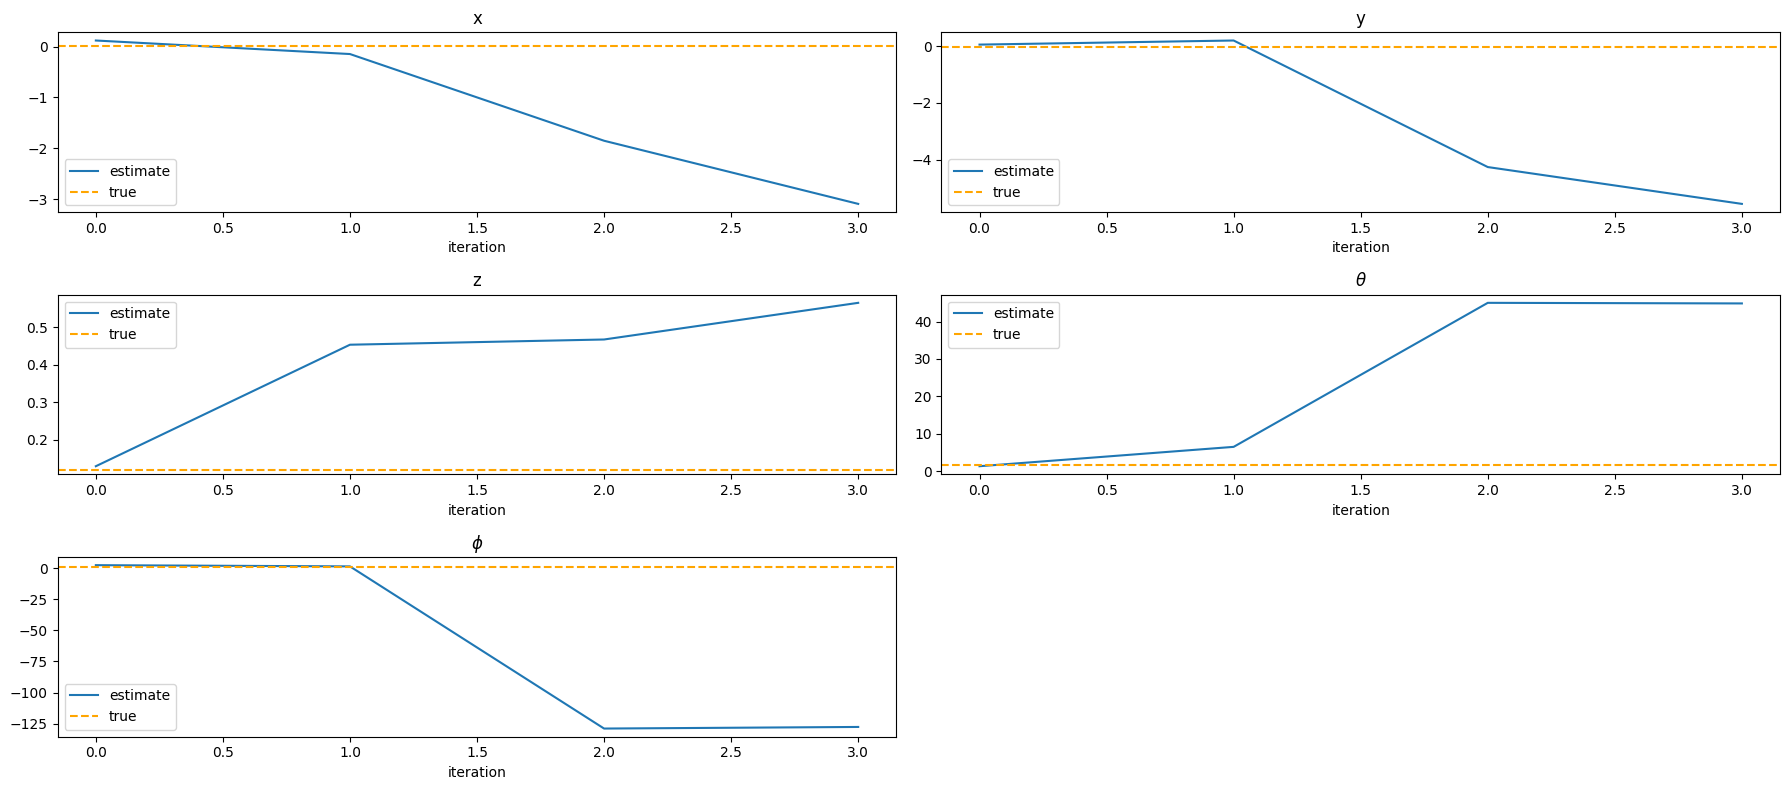

In [21]:
xs = np.array(xs_pred)                      # (n_iters, 5)
labels = ['x', 'y', 'z', r'$\theta$', r'$\phi$']

fig, axes = plt.subplots(3, 2, figsize=(18, 8))
for k, ax in enumerate(axes.flat):
    if k >= xs.shape[1]:
        ax.set_visible(False)
        continue
    ax.plot(xs[:, k], label='estimate')
    ax.axhline(x_true[k], color='orange', linestyle='--', label='true')
    ax.set_title(labels[k])
    ax.set_xlabel('iteration')
    ax.legend()
plt.tight_layout()
plt.show()